# Projeto MEGA - Análise Semanal Automatizada e EDA

Este notebook identifica automaticamente o alvo de maior impacto, consolida os dados semanalmente e apresenta uma análise visual profunda para suportar a Árvore de Decisão.

In [9]:
# Instalação de biblioteca de feriados
try:
    import holidays
except ImportError:
    !pip install holidays
    import holidays

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# Carga de dados
target_file = 'data/database_final.csv'
df = pd.read_csv(target_file, low_memory=False)
df['DATA_ATEND'] = pd.to_datetime(df['DATA_ATEND'])

print(f"Tamanho do DataFrame original: {df.shape}")

Tamanho do DataFrame original: (556198, 13)


## 1. Seleção Automática de Categoria e Filial
Identificando o par com maior volume de registros.

In [10]:
top_alvo = df.groupby(['CATEGORIA', 'FILIAL']).size().reset_index(name='CONTAGEM')
top_alvo = top_alvo.sort_values(by='CONTAGEM', ascending=False).iloc[0]

cat_alvo = top_alvo['CATEGORIA']
filial_alvo = top_alvo['FILIAL']

print(f"Alvo Selecionado: {cat_alvo} na {filial_alvo} ({top_alvo['CONTAGEM']} registros)")

df_filtrado = df[(df['CATEGORIA'] == cat_alvo) & (df['FILIAL'] == filial_alvo)].copy()

Alvo Selecionado: Temperos & Condimentos na SHOPPING (91755 registros)


## 2. Agregação Semanal e Detecção de Feriados

In [11]:
df_semanal = df_filtrado.set_index('DATA_ATEND').resample('W')['FATUR_VENDA'].sum().reset_index()
df_semanal.columns = ['DATA_INICIO_SEMANA', 'DEMANDA_ALVO']

br_holidays = holidays.Brazil()

def verificar_feriado(row):
    data_fim = row['DATA_INICIO_SEMANA']
    periodo = pd.date_range(start=data_fim - pd.Timedelta(days=6), end=data_fim)
    for data in periodo:
        if data in br_holidays: return 1
    return 0

df_semanal['MES'] = df_semanal['DATA_INICIO_SEMANA'].dt.month
df_semanal['TEM_FERIADO'] = df_semanal.apply(verificar_feriado, axis=1)

## 3. Visualização e Análise de Dados (EDA)

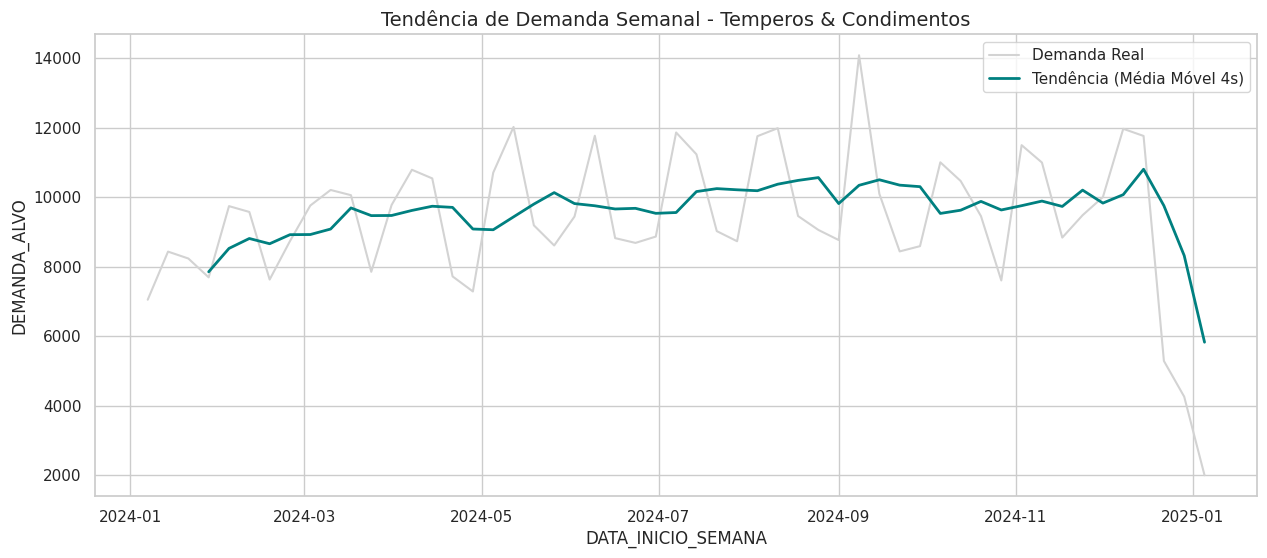

In [12]:
# A. Série Temporal e Tendência (Média Móvel de 4 semanas)
df_semanal['TENDENCIA'] = df_semanal['DEMANDA_ALVO'].rolling(window=4).mean()

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_semanal, x='DATA_INICIO_SEMANA', y='DEMANDA_ALVO', label='Demanda Real', color='lightgrey')
sns.lineplot(data=df_semanal, x='DATA_INICIO_SEMANA', y='TENDENCIA', label='Tendência (Média Móvel 4s)', color='teal', linewidth=2)
plt.title(f'Tendência de Demanda Semanal - {cat_alvo}', fontsize=14)
plt.legend()
plt.show()

/tmp/ipykernel_282506/2172196278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_semanal, x='TEM_FERIADO', y='DEMANDA_ALVO', palette='Set2', ax=axes[0])
/tmp/ipykernel_282506/2172196278.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sem Feriado', 'Com Feriado'])
/tmp/ipykernel_282506/2172196278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_semanal, x='MES', y='DEMANDA_ALVO', palette='viridis', ax=axes[1])


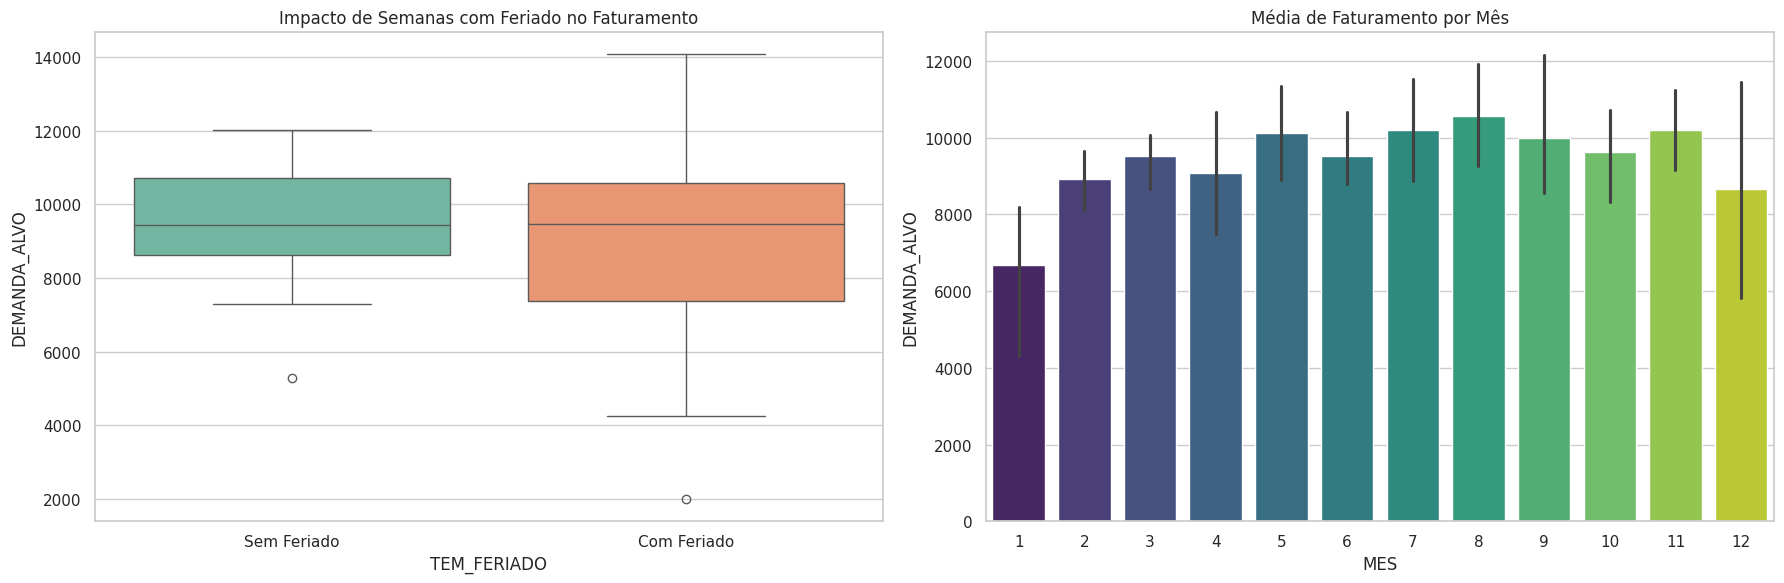

In [13]:
# B. Impacto do Feriado e Sazonalidade Mensal
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=df_semanal, x='TEM_FERIADO', y='DEMANDA_ALVO', palette='Set2', ax=axes[0])
axes[0].set_title('Impacto de Semanas com Feriado no Faturamento')
axes[0].set_xticklabels(['Sem Feriado', 'Com Feriado'])

sns.barplot(data=df_semanal, x='MES', y='DEMANDA_ALVO', palette='viridis', ax=axes[1])
axes[1].set_title('Média de Faturamento por Mês')

plt.tight_layout()
plt.show()

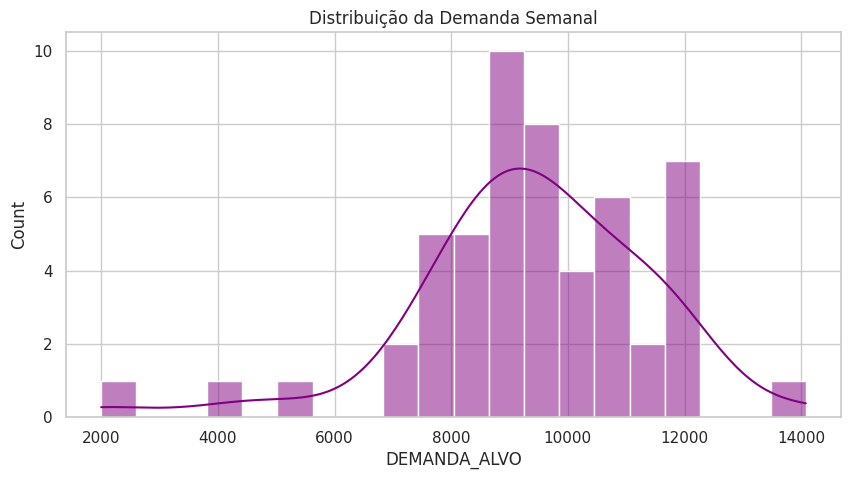

In [14]:
# C. Distribuição de Frequência da Demanda
plt.figure(figsize=(10, 5))
sns.histplot(df_semanal['DEMANDA_ALVO'], kde=True, color='purple', bins=20)
plt.title('Distribuição da Demanda Semanal')
plt.show()

## 4. Definição de Níveis Semanais (Thresholds)

In [15]:
q33 = df_semanal['DEMANDA_ALVO'].quantile(0.33)
q66 = df_semanal['DEMANDA_ALVO'].quantile(0.66)
v_max = df_semanal['DEMANDA_ALVO'].max()

print("=== LIMITES SEMANAIS CALCULADOS ===")
print(f"Demanda Baixa: Até R$ {q33:.2f}")
print(f"Demanda Média: Entre R$ {q33:.2f} e R$ {q66:.2f}")
print(f"Demanda Alta: Acima de R$ {q66:.2f}")

=== LIMITES SEMANAIS CALCULADOS ===
Demanda Baixa: Até R$ 8739.35
Demanda Média: Entre R$ 8739.35 e R$ 10066.61
Demanda Alta: Acima de R$ 10066.61
